In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyekfmm as fmm
import os
import seaborn as sns
from matplotlib import gridspec

np.random.seed(0)
import sys
print(sys.path)

# device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

result_path = "./result/figs/GRSL/GeoFWI/"
os.makedirs(result_path, exist_ok=True)

['', '/opt/madagascar/lib/python3.10/site-packages', '/home/g202321530/anaconda3/envs/pytorch/lib/python312.zip', '/home/g202321530/anaconda3/envs/pytorch/lib/python3.12', '/home/g202321530/anaconda3/envs/pytorch/lib/python3.12/lib-dynload', '/home/g202321530/anaconda3/envs/pytorch/lib/python3.12/site-packages']


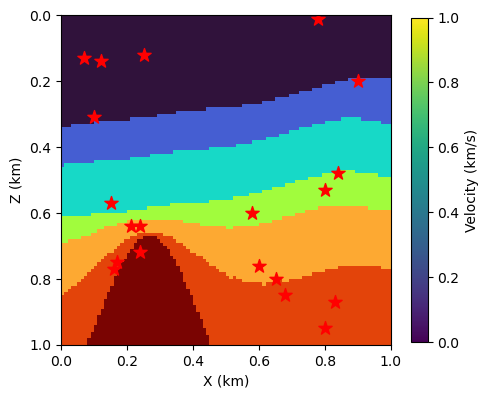

source location: 60 76
source location: 78 1
source location: 24 64
source location: 58 60
source location: 12 14
source location: 17 75
source location: 24 72
source location: 10 31
source location: 68 85
source location: 65 80
source location: 16 77
source location: 15 57
source location: 7 13
source location: 80 53
source location: 84 48
source location: 83 87
source location: 90 20
source location: 21 64
source location: 25 12
source location: 80 95
Final shapes:
T0_data_all: (20, 100, 100)
vel_data_all: (20, 100, 100)
src_data_all: (20, 100, 100)
Tau_data_all: (20, 100, 100)


In [2]:
# Hyperparameters
n_sources = 20 # num of src 
# ntrain = 30 
T0_data_all = []
T_data_all = []
vel_data_all = []
src_data_all = []

velz = np.load('/home/g202321530/Yang/Data/GeoFWI/GeoFWI_5layer_salt_example_1.npy')
velz = velz/1000

# Parameters setup
nx, nz = velz.shape
dx, dz = 0.01, 0.01  # Grid spacing in km

# Generate random source points
np.random.seed(20252025)  # For reproducibility
source_locs = np.random.randint(0, nx, size=(n_sources, 2)).astype('float32')  # [x, z] pairs in index space
source_locs_physical = source_locs * dx  # Convert to physical coordinates (km)

# Generate random source points
np.random.seed(202502)  # For reproducibility
source_locs1 = np.random.randint(0, nx, size=(40, 2)).astype('float32')  # [x, z] pairs in index space
source_locs_physical1 = source_locs1 * dx  # Convert to physical coordinates (km)

# Visualization
plt.figure(figsize=(5, 5))
plt.imshow(velz, extent=[0, nx*dx, nz*dz, 0], cmap='turbo')
plt.scatter(source_locs_physical[:, 0], source_locs_physical[:, 1], c='red', marker='*', s=100)
plt.xlabel('X (km)')
plt.ylabel('Z (km)')
# plt.title(f'Velocity Model {model_idx} with Sources')
cbar = plt.colorbar(shrink=0.7)
cbar.set_label(r'Velocity (km/s)')  # Assuming velocity, not density
plt.tight_layout()
plt.show()

# Initialize arrays for this model
T_data = np.zeros((n_sources, nx, nz), dtype='float32')
T0_data = np.zeros((n_sources, nx, nz), dtype='float32')
vel_data = np.zeros((n_sources, nx, nz), dtype='float32')
src_data = np.zeros((n_sources, nx, nz), dtype='float32')  # 2 channels for x, z coordinates

# Calculate traveltime fields for each source
for src_idx, (sx, sz) in enumerate(source_locs):
    sx, sz = int(sx), int(sz)  # Convert to integer indices
    print('source location:', int(sx), int(sz))
    src_physical = np.array([sx * dx, sz * dz], dtype='float32')  # [x, z] in km
    
    # Populate velocity data
    vel_data[src_idx] = velz
    
    # Populate source data (x, z coordinates across the grid)
    src_data[src_idx, sz, sx] = 1


    # Heterogeneous velocity computation
    velz_1d = velz.reshape([nx * nz], order='F')  # 1D for fmm
    t = fmm.eikonal(
        velz_1d,
        xyz=np.array([src_physical[0], 0, src_physical[1]]),
        ax=[0, dx, nx],
        ay=[0, dx, 1],
        az=[0, dz, nz],
        order=2
    )
    T_data[src_idx] = t.reshape(nx, nz, order='F').T
    
    # Homogeneous velocity computation
    vel_homo = velz[sx, sz] * np.ones([nx * nz], dtype='float32')
    t1 = fmm.eikonal(
        vel_homo,
        xyz=np.array([src_physical[0], 0, src_physical[1]]),
        ax=[0, dx, nx],
        ay=[0, dx, 1],
        az=[0, dz, nz],
        order=2
    )
    T0_data[src_idx] = t1.reshape(nx, nz, order='F').T
    
    # Append to all data
    T_data_all.append(T_data[src_idx])
    T0_data_all.append(T0_data[src_idx])
    vel_data_all.append(vel_data[src_idx])
    src_data_all.append(src_data[src_idx])
    
# Convert to numpy arrays
T0_data_all = np.array(T0_data_all)      # Shape: (n_models * n_sources, nx, nz)
T_data_all = np.array(T_data_all)        # Shape: (n_models * n_sources, nx, nz)
vel_data_all = np.array(vel_data_all)    # Shape: (n_models * n_sources, nx, nz)
src_data_all = np.array(src_data_all)    # Shape: (n_models * n_sources, nx, nz, 2)
Tau_data_all = T_data_all - T0_data_all  # Shape: (n_models * n_sources, nx, nz)

print("Final shapes:")
print(f"T0_data_all: {T0_data_all.shape}")
print(f"vel_data_all: {vel_data_all.shape}")
print(f"src_data_all: {src_data_all.shape}")
print(f"Tau_data_all: {Tau_data_all.shape}")

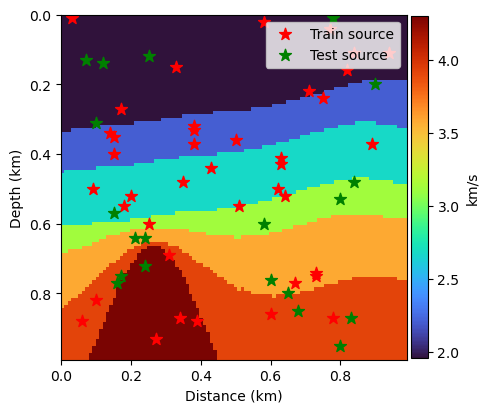

In [3]:
    # # Visualization
    # plt.figure(figsize=(5, 5))
    # plt.imshow(velz, extent=[0, nx*dx, nz*dz, 0], cmap='turbo')
    # plt.scatter(source_locs_physical[:, 0], source_locs_physical[:, 1], c='red', marker='*', s=100)
    # plt.xlabel('X (km)')
    # plt.ylabel('Z (km)')
    # plt.title(f'Velocity Model {model_idx} with Sources')
    # cbar = plt.colorbar(shrink=0.7)
    # cbar.set_label(r'Velocity (km/s)')  # Assuming velocity, not density
    # plt.tight_layout()
    # plt.show()
plt.figure(figsize=(5, 5))
plt.imshow(velz, extent=[0, (nx-1)*dx, (nz-1)*dz, 0], cmap='turbo')
# plt.title('Source distributions')
plt.colorbar(shrink=0.75, label='km/s', 
                   pad=0.01)
plt.scatter(source_locs_physical1[:, 0], source_locs_physical1[:, 1], 
           c='red', marker='*', s=80, label='Train source')
plt.scatter(source_locs_physical[:, 0], source_locs_physical[:, 1], c='green', marker='*', s=80, label='Test source')
plt.xlabel('Distance (km)')
plt.ylabel('Depth (km)')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig(f'{result_path}Geofwi_src_distributions_FNO_and_KAGFNO.png', bbox_inches='tight', dpi=300)
plt.savefig(f'{result_path}Geofwi_src_distributions_FNO_and_KAGFNO.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [4]:
################################################################
# Load Prediction
################################################################
epochs = 3000
FNO_tau = np.load(f'./prediction/Vanilla_FNO/GeoFWI_Salt/Vanilla_FNO_Pred_Tau_src{n_sources}_ep{epochs}.npy')
KAGFNO_tau = np.load(f'./prediction/KAGFNO/GeoFWI_Salt/KAGFNO_Pred_Tau_src{n_sources}_ep{epochs}.npy')

KAGFNO_tau.shape

(20, 100, 100, 1)

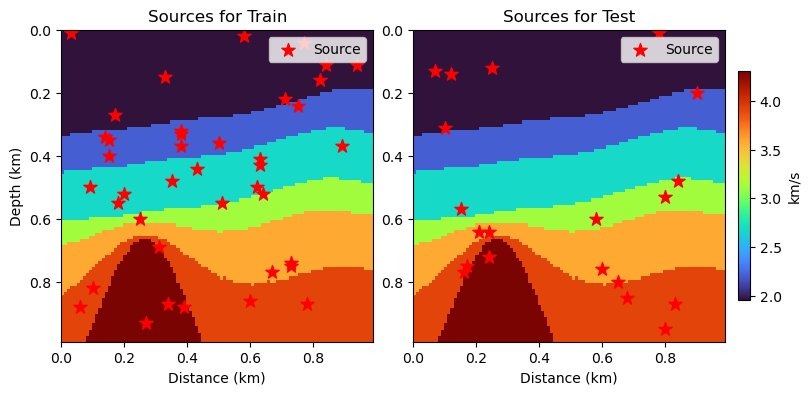

In [5]:
# Create figure and subplots with shared colorbar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), 
                              constrained_layout=True, 
                              gridspec_kw={'width_ratios': [1, 1]})  # Equal width

# Subplot 1: Velocity model with sources for train
im1 = ax1.imshow(velz, extent=[0, (nx-1)*dx, (nz-1)*dz, 0], 
                cmap='turbo', aspect='equal')
ax1.scatter(source_locs_physical1[:, 0], source_locs_physical1[:, 1], 
           c='red', marker='*', s=100, label='Source')
ax1.set_xlabel('Distance (km)')
ax1.set_ylabel('Depth (km)')
ax1.set_title('Sources for Train', fontsize=12)
ax1.legend(loc='upper right')

# Subplot 2: Velocity model with sources for test
im2 = ax2.imshow(velz, extent=[0, (nx-1)*dx, (nz-1)*dz, 0], 
                cmap='turbo', aspect='equal')
ax2.scatter(source_locs_physical[:, 0], source_locs_physical[:, 1], 
           c='red', marker='*', s=100, label='Source')
ax2.set_xlabel('Distance (km)')
# ax2.set_ylabel('Depth (km)')  # Commented out as in original
ax2.set_title('Sources for Test', fontsize=12)
ax2.legend(loc='upper right')

# Add single colorbar
cbar = fig.colorbar(im1, ax=[ax1, ax2], shrink=0.6, label='km/s', 
                   pad=0.02)  # Adjust shrink and pad as needed

# Ensure equal aspect ratios and tight layout
ax1.set_aspect('equal')
ax2.set_aspect('equal')

# plt.savefig(f'{result_path}Curv_src_distribution_FNO_and_KAGFNO_ep{epochs}.png', bbox_inches='tight', dpi=300)
# plt.savefig(f'{result_path}Curv_src_distribution_FNO_and_KAGFNO_ep{epochs}.pdf', bbox_inches='tight', dpi=300)
plt.show()

MSE Statistics (across 50 sources):
Mean FNO: 2.690e-05	KAGFNO: 2.006e-05
Std FNO: 4.360e-05	KAGFNO: 5.444e-05
Min FNO: 2.949e-06	KAGFNO: 6.846e-07
Max FNO: 2.020e-04	KAGFNO: 2.523e-04


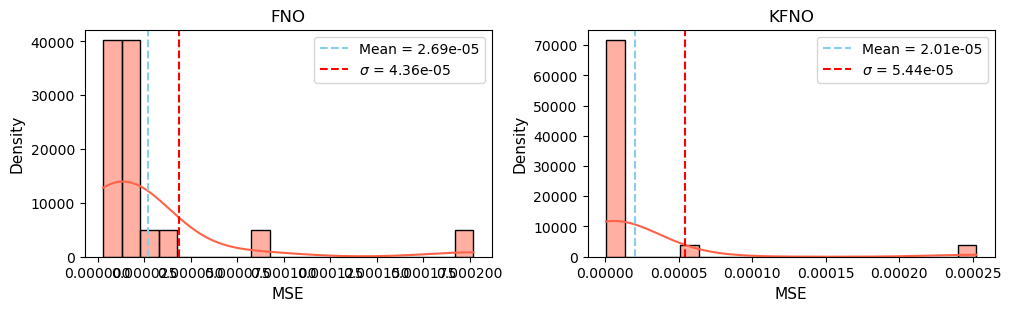

In [6]:
# Calculate MSE per source
mse_FNO = np.mean((Tau_data_all - FNO_tau[:, :, :, 0]) ** 2, axis=(1, 2))
mse_KAGFNO = np.mean((Tau_data_all - KAGFNO_tau[:, :, :, 0]) ** 2, axis=(1, 2))

# Print some statistics
print(f"MSE Statistics (across 50 sources):")
print(f"Mean FNO: {np.mean(mse_FNO):.3e}\tKAGFNO: {np.mean(mse_KAGFNO):.3e}")
print(f"Std FNO: {np.std(mse_FNO):.3e}\tKAGFNO: {np.std(mse_KAGFNO):.3e}")
print(f"Min FNO: {np.min(mse_FNO):.3e}\tKAGFNO: {np.min(mse_KAGFNO):.3e}")
print(f"Max FNO: {np.max(mse_FNO):.3e}\tKAGFNO: {np.max(mse_KAGFNO):.3e}")

# Create figure and subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3), 
                              constrained_layout=True, 
                              gridspec_kw={'width_ratios': [1, 1]})  # Equal width

# Subplot 1: MSE histogram for FNO
sns.histplot(data=mse_FNO, bins=20, kde=True, color='tomato', 
             stat='density', alpha=0.5, ax=ax1)
ax1.axvline(np.mean(mse_FNO), color='skyblue', linestyle='--', 
            label=f'Mean = {np.mean(mse_FNO):.2e}')
ax1.axvline(np.std(mse_FNO), color='red', linestyle='--', 
            label=f'$\\sigma$ = {np.std(mse_FNO):.2e}')
ax1.set_xlabel('MSE', fontsize=11)
ax1.set_ylabel('Density', fontsize=11)
ax1.set_title('FNO', fontsize=12)
ax1.legend(fontsize=10)

# Subplot 2: MSE histogram for KAGFNO
sns.histplot(data=mse_KAGFNO, bins=20, kde=True, color='tomato', 
             stat='density', alpha=0.5, ax=ax2)
ax2.axvline(np.mean(mse_KAGFNO), color='skyblue', linestyle='--', 
            label=f'Mean = {np.mean(mse_KAGFNO):.2e}')
ax2.axvline(np.std(mse_KAGFNO), color='red', linestyle='--', 
            label=f'$\\sigma$ = {np.std(mse_KAGFNO):.2e}')
ax2.set_xlabel('MSE', fontsize=11)
ax2.set_ylabel('Density', fontsize=11)
ax2.set_title('KFNO', fontsize=12)
ax2.legend(fontsize=10)

# plt.savefig(f'{result_path}Curv_MSE_distribution_FNO_and_KAGFNO_ep{epochs}.png', bbox_inches='tight', dpi=300)
# plt.savefig(f'{result_path}Curv_MSE_distribution_FNO_and_KAGFNO_ep{epochs}.pdf', bbox_inches='tight', dpi=300)
plt.show()

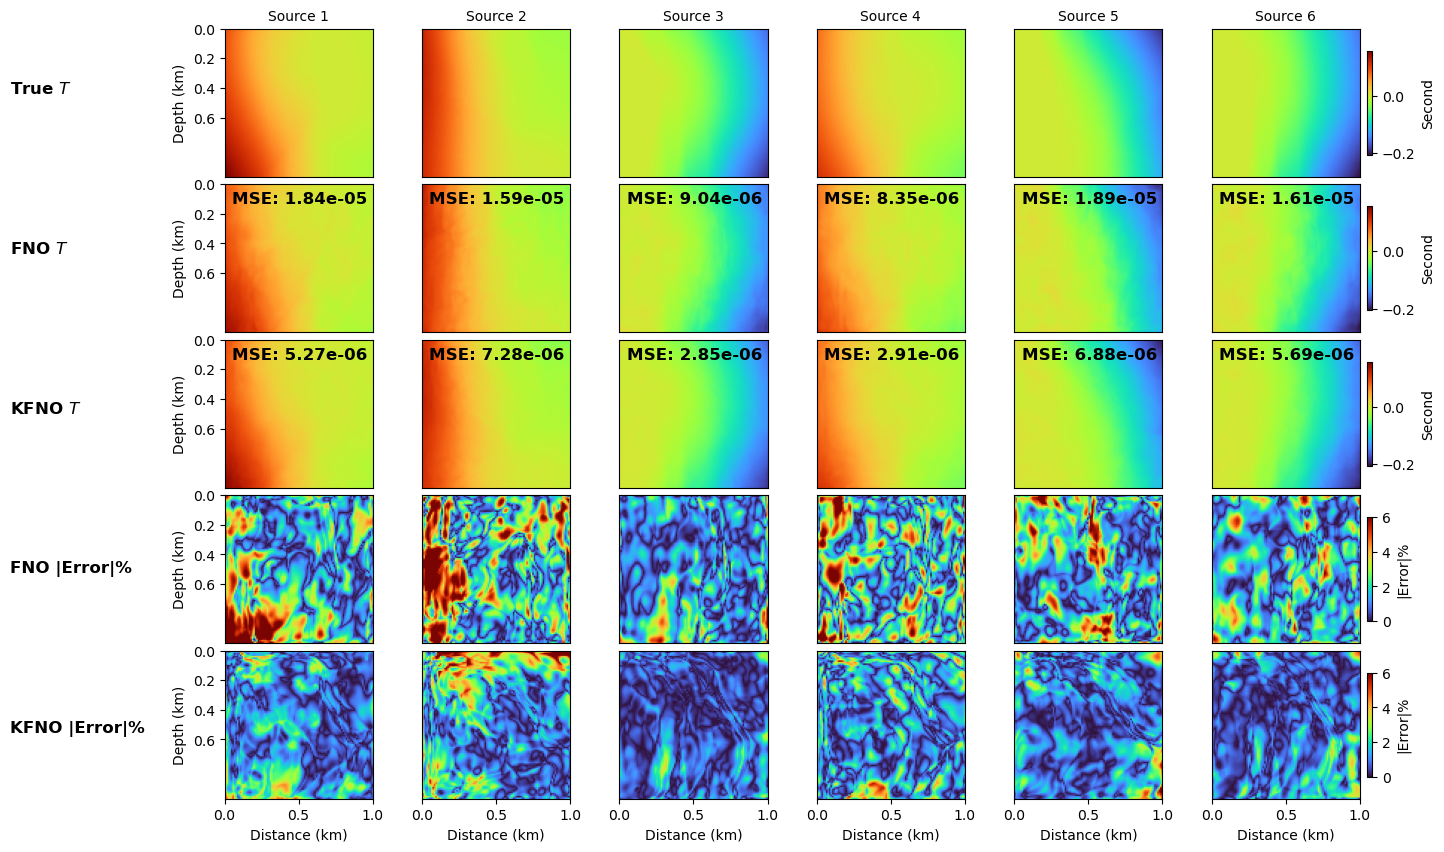

In [9]:
index=0

# Create figure and axes
fig, axes = plt.subplots(5, 6, figsize=(18, 10))
plt.subplots_adjust(wspace=0.03, hspace=0.05)

# First pass: Compute global min/max and max_ape
vmin_true_pred = float('inf')
vmax_true_pred = float('-inf')
max_ape = 0
for i in range(6):
    true_data = Tau_data_all[i+index, :, :]
    pred_FNO = FNO_tau[i+index, :, :, 0]
    pred_KFNO = KAGFNO_tau[i+index, :, :, 0]
    vmin_true_pred = min(vmin_true_pred, true_data.min(), pred_FNO.min(), pred_KFNO.min())
    vmax_true_pred = max(vmax_true_pred, true_data.max(), pred_FNO.max(), pred_KFNO.max())
    max_true = np.max(np.abs(true_data))
    if max_true > 0:
        ape_FNO = (np.abs(pred_FNO - true_data) / max_true) * 100
        ape_KFNO = (np.abs(pred_KFNO - true_data) / max_true) * 100
        max_ape = max(max_ape, np.max(ape_FNO), np.max(ape_KFNO))

# Second pass: Plotting
for i in range(6):
    # Prepare data
    true_data = Tau_data_all[i + index, :, :] 
    pred_FNO = FNO_tau[i + index, :, :, 0]
    pred_KFNO = KAGFNO_tau[i + index, :, :, 0]
    max_true = np.max(np.abs(true_data))
    
    # Calculate Mean Squared Error (MSE)
    mse_FNO = np.mean((pred_FNO - true_data) ** 2)
    mse_KFNO = np.mean((pred_KFNO - true_data) ** 2)
    
    # Plotting extent
    extent = [0, nx * dx, nz * dz, 0]
    
    # Row 0: Ground Truth
    axes[0, i].imshow(true_data[::-1, :], extent=extent, cmap='turbo', vmin=vmin_true_pred, vmax=vmax_true_pred)
    axes[0, i].set_title(f'Source {i + 1}', fontsize=10)
    axes[0, i].set_xticks([])
    axes[0, i].set_yticks([])
    
    # Row 1: FNO Prediction
    axes[1, i].imshow(pred_FNO[::-1, :], extent=extent, cmap='turbo', vmin=vmin_true_pred, vmax=vmax_true_pred)
    axes[1, i].text(0.05, 0.95, f'MSE: {mse_FNO:.2e}', transform=axes[1, i].transAxes,
                    fontsize=12, color='black', fontweight='bold', va='top')
    axes[1, i].set_xticks([])
    axes[1, i].set_yticks([])
    
    # Row 2: KFNIE Prediction
    axes[2, i].imshow(pred_KFNO[::-1, :], extent=extent, cmap='turbo', vmin=vmin_true_pred, vmax=vmax_true_pred)
    axes[2, i].text(0.05, 0.95, f'MSE: {mse_KFNO:.2e}', transform=axes[2, i].transAxes,
                    fontsize=12, color='black', fontweight='bold', va='top')
    axes[2, i].set_xticks([])
    axes[2, i].set_yticks([])
    
    # Row 3: APE for FNO
    ape_FNO = (np.abs(pred_FNO[::-1, :] - true_data[::-1, :]) / max_true) * 100 if max_true > 0 else np.zeros_like(true_data)
    axes[3, i].imshow(ape_FNO, extent=extent, cmap='turbo', vmin=0, vmax=6)
    axes[3, i].set_xticks([])
    axes[3, i].set_yticks([])
    
    # Row 4: APE for KFNO
    ape_KFNO = (np.abs(pred_KFNO[::-1, :] - true_data[::-1, :]) / max_true) * 100 if max_true > 0 else np.zeros_like(true_data)
    axes[4, i].imshow(ape_KFNO, extent=extent, cmap='turbo', vmin=0, vmax=6)
    # axes[4, i].set_xticks([])
    axes[4, i].set_yticks([])
    axes[4, i].set_xlabel('Distance (km)')
    
    # Row 5: Contour Plot
    # axes[5, i].imshow(velz, extent=extent, cmap='turbo')
    # cont_true = axes[5, i].contour(T_data_all[i + index, :, :], 10, colors='red', linewidths=2,
    #                                extent=extent, linestyles='solid')
    # cont_FNO = axes[5, i].contour(FNO_tau[i + index, :, :, 0] + T0_data_all[i + index, :, :], 10,
    #                               colors='black', linewidths=2, extent=extent, linestyles='dashed')
    # cont_KFNO = axes[5, i].contour(KAGFNO_tau[i + index, :, :, 0] + T0_data_all[i + index, :, :], 10,
    #                                colors='#00FF00', linewidths=2, extent=extent, linestyles='dotted')
    # axes[5, i].set_yticks([])
    
    # # Add x-label and xticks to bottom row
    # axes[5, i].set_xlabel('Distance (km)')
    # axes[5, i].set_xticks([0, nx * dx / 2, nx * dx])
    
    # Add y-labels and yticks to first column
    if i == 0:
        for j in range(5):
            axes[j, i].set_ylabel('Depth (km)')
            axes[j, i].set_yticks([0, 0.2, 0.4, 0.6])

    # # Add legend to first contour plot
    # if i == 0:
    #     h1, _ = cont_true.legend_elements()
    #     h2, _ = cont_FNO.legend_elements()
    #     h3, _ = cont_KFNO.legend_elements()
    #     axes[5, 0].legend([h1[0], h2[0], h3[0]], ['Truth', 'FNO', 'KFNO'], fontsize=9, loc='upper left')

# Add row titles
row_titles = ['True $T$', 'FNO $T$', 'KFNO $T$', 'FNO |Error|%', 'KFNO |Error|%']
for j, title in enumerate(row_titles):
    fig.text(0.03, 0.82 - j * 0.16, title, va='center', ha='left', fontsize=12, fontweight='bold')

# Add colorbars for each row
for row, label in [
    (0, 'Second'),
    (1, 'Second'),
    (2, 'Second'),
    (3, '|Error|%'),
    (4, '|Error|%')
    # (5, 'km/s')
]:
    cbar = fig.colorbar(axes[row, 0].images[0], ax=axes[row, :], shrink=0.7, pad=0.005, location='right')
    cbar.set_label(label)

plt.savefig(f'{result_path}GRSL_GeoFWI_Salt_comparison_FNO_and_KAGFNO_Tau_ep{epochs}.png', bbox_inches='tight', dpi=300)
plt.savefig(f'{result_path}GRSL_GeoFWI_Salt_comparison_FNO_and_KAGFNO_Tau_ep{epochs}.pdf', bbox_inches='tight', dpi=300)
plt.show()

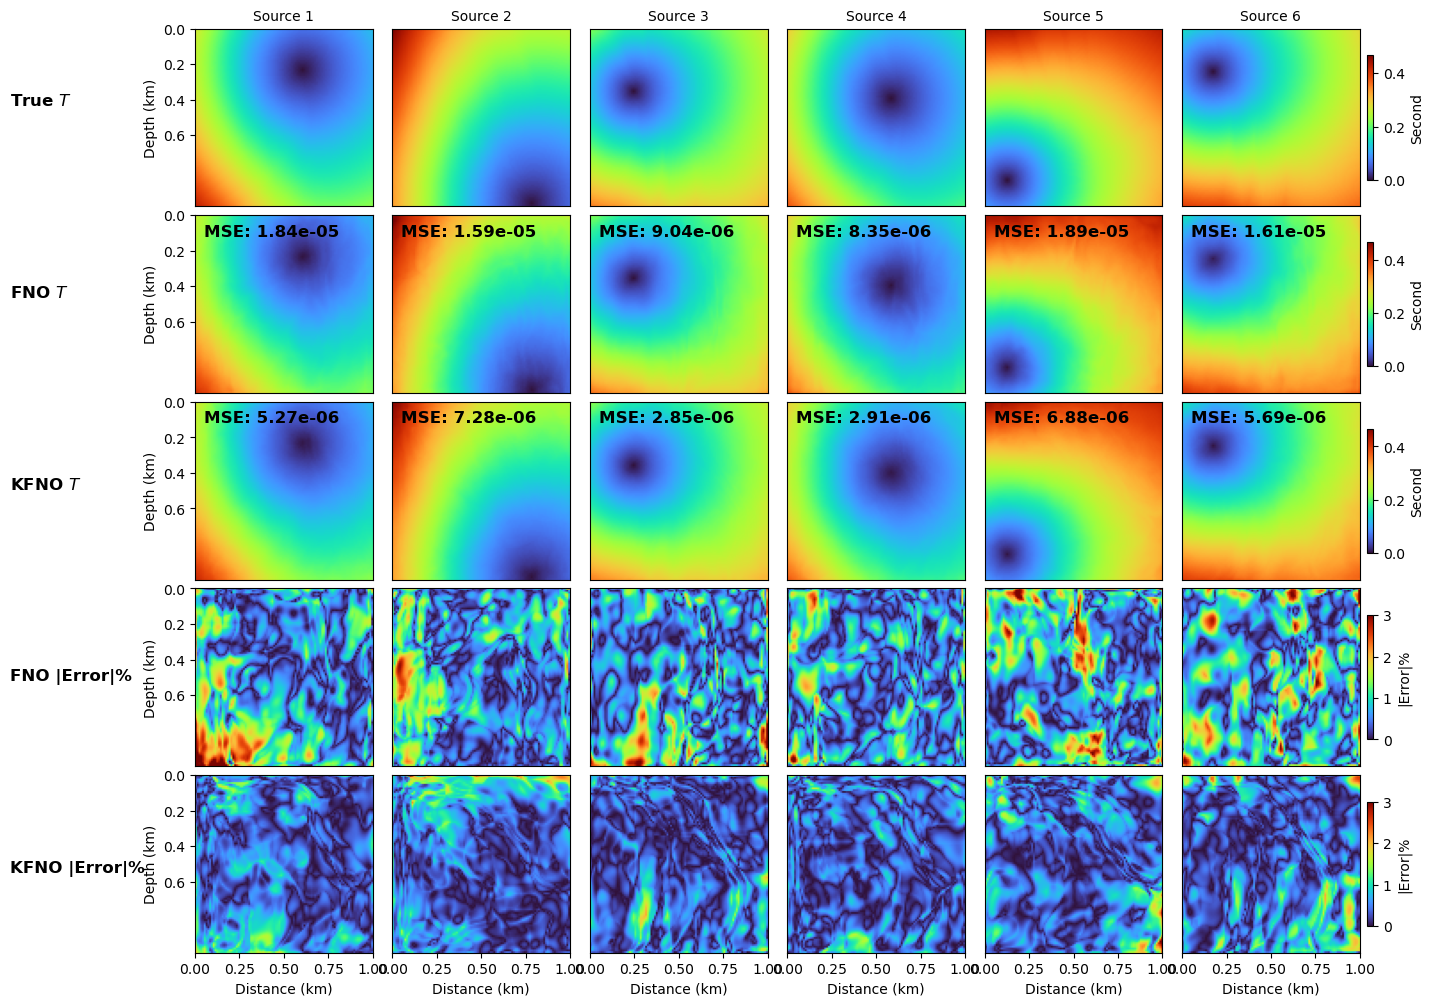

In [10]:
index=0

# Create figure and subplots (6 rows, 5 columns)
fig, axes = plt.subplots(5, 6, figsize=(18, 12))
plt.subplots_adjust(wspace=0.03, hspace=0.05)

# First pass: Compute global min/max and max absolute percentage error (APE)
vmin_true_pred = float('inf')
vmax_true_pred = float('-inf')
max_ape = 0
for i in range(6):
    true_data = Tau_data_all[i + index, :, :] + T0_data_all[i + index, :, :]
    pred_FNO = FNO_tau[i + index, :, :, 0] + T0_data_all[i + index, :, :]
    pred_KFNO = KAGFNO_tau[i + index, :, :, 0] + T0_data_all[i + index, :, :]
    
    vmin_true_pred = min(vmin_true_pred, true_data.min(), pred_FNO.min(), pred_KFNO.min())
    vmax_true_pred = max(vmax_true_pred, true_data.max(), pred_FNO.max(), pred_KFNO.max())
    
    max_true = np.max(np.abs(true_data))
    if max_true > 0:
        ape_FNO = (np.abs(pred_FNO - true_data) / max_true) * 100
        ape_KFNO = (np.abs(pred_KFNO - true_data) / max_true) * 100
        max_ape = max(max_ape, np.max(ape_FNO), np.max(ape_KFNO))

# Second pass: Plotting
for i in range(6):
    # Prepare data
    true_data = Tau_data_all[i + index, :, :] + T0_data_all[i + index, :, :]
    pred_FNO = FNO_tau[i + index, :, :, 0] + T0_data_all[i + index, :, :]
    pred_KFNO = KAGFNO_tau[i + index, :, :, 0] + T0_data_all[i + index, :, :]
    max_true = np.max(np.abs(true_data))
    
    # Calculate Mean Squared Error (MSE)
    mse_FNO = np.mean((pred_FNO - true_data) ** 2)
    mse_KFNO = np.mean((pred_KFNO - true_data) ** 2)
    
    # Plotting extent
    extent = [0, nx * dx, nz * dz, 0]
    
    # Row 0: Ground Truth
    axes[0, i].imshow(true_data[::-1, :], extent=extent, cmap='turbo', vmin=vmin_true_pred, vmax=vmax_true_pred)
    axes[0, i].set_title(f'Source {i + 1}', fontsize=10)
    axes[0, i].set_xticks([])
    axes[0, i].set_yticks([])
    
    # Row 1: FNO Prediction
    axes[1, i].imshow(pred_FNO[::-1, :], extent=extent, cmap='turbo', vmin=vmin_true_pred, vmax=vmax_true_pred)
    axes[1, i].text(0.05, 0.95, f'MSE: {mse_FNO:.2e}', transform=axes[1, i].transAxes,
                    fontsize=12, color='black', fontweight='bold', va='top')
    axes[1, i].set_xticks([])
    axes[1, i].set_yticks([])
    
    # Row 2: KFNIE Prediction
    axes[2, i].imshow(pred_KFNO[::-1, :], extent=extent, cmap='turbo', vmin=vmin_true_pred, vmax=vmax_true_pred)
    axes[2, i].text(0.05, 0.95, f'MSE: {mse_KFNO:.2e}', transform=axes[2, i].transAxes,
                    fontsize=12, color='black', fontweight='bold', va='top')
    axes[2, i].set_xticks([])
    axes[2, i].set_yticks([])
    
    # Row 3: APE for FNO
    ape_FNO = (np.abs(pred_FNO[::-1, :] - true_data[::-1, :]) / max_true) * 100 if max_true > 0 else np.zeros_like(true_data)
    axes[3, i].imshow(ape_FNO, extent=extent, cmap='turbo', vmin=0, vmax=3)
    axes[3, i].set_xticks([])
    axes[3, i].set_yticks([])
    
    # Row 4: APE for KFNO
    ape_KFNO = (np.abs(pred_KFNO[::-1, :] - true_data[::-1, :]) / max_true) * 100 if max_true > 0 else np.zeros_like(true_data)
    axes[4, i].imshow(ape_KFNO, extent=extent, cmap='turbo', vmin=0, vmax=3)
    # axes[4, i].set_xticks([])
    axes[4, i].set_yticks([])
    axes[4, i].set_xlabel('Distance (km)')
    
    # Row 5: Contour Plot
    # axes[5, i].imshow(velz, extent=extent, cmap='turbo')
    # cont_true = axes[5, i].contour(T_data_all[i + index, :, :], 10, colors='red', linewidths=2,
    #                                extent=extent, linestyles='solid')
    # cont_FNO = axes[5, i].contour(FNO_tau[i + index, :, :, 0] + T0_data_all[i + index, :, :], 10,
    #                               colors='black', linewidths=2, extent=extent, linestyles='dashed')
    # cont_KFNO = axes[5, i].contour(KAGFNO_tau[i + index, :, :, 0] + T0_data_all[i + index, :, :], 10,
    #                                colors='#00FF00', linewidths=2, extent=extent, linestyles='dotted')
    # axes[5, i].set_yticks([])
    
    # # Add x-label and xticks to bottom row
    # axes[5, i].set_xlabel('Distance (km)')
    # axes[5, i].set_xticks([0, nx * dx / 2, nx * dx])
    
    # Add y-labels and yticks to first column
    if i == 0:
        for j in range(5):
            axes[j, i].set_ylabel('Depth (km)')
            axes[j, i].set_yticks([0, 0.2, 0.4, 0.6])

    # # Add legend to first contour plot
    # if i == 0:
    #     h1, _ = cont_true.legend_elements()
    #     h2, _ = cont_FNO.legend_elements()
    #     h3, _ = cont_KFNO.legend_elements()
    #     axes[5, 0].legend([h1[0], h2[0], h3[0]], ['Truth', 'FNO', 'KFNO'], fontsize=9, loc='upper left')

# Add row titles
row_titles = ['True $T$', 'FNO $T$', 'KFNO $T$', 'FNO |Error|%', 'KFNO |Error|%']
for j, title in enumerate(row_titles):
    fig.text(0.03, 0.82 - j * 0.16, title, va='center', ha='left', fontsize=12, fontweight='bold')

# Add colorbars for each row
for row, label in [
    (0, 'Second'),
    (1, 'Second'),
    (2, 'Second'),
    (3, '|Error|%'),
    (4, '|Error|%')
    # (5, 'km/s')
]:
    cbar = fig.colorbar(axes[row, 0].images[0], ax=axes[row, :], shrink=0.7, pad=0.005, location='right')
    cbar.set_label(label)

plt.savefig(f'{result_path}GRSL_GeoFWI_Salt_comparison_FNO_and_KAGFNO_T_ep{epochs}.png', bbox_inches='tight', dpi=300)
plt.savefig(f'{result_path}GRSL_GeoFWI_Salt_comparison_FNO_and_KAGFNO_T_ep{epochs}.pdf', bbox_inches='tight', dpi=300)
plt.show()